# Topic analysis

In [ ]:
import pandas as pd
from pathlib import Path
import zipfile
import re

import re
from pathlib import Path

import pandas as pd

# NLP / ML
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# 修改为你的云端硬盘路径
DATA_DIR = '/content/drive/MyDrive/UU/MSD/'
DATA_DIR

Mounted at /content/drive


'/content/drive/MyDrive/UU/MSD/'

In [ ]:
entries_en_path  = Path(DATA_DIR) / 'entries1_en.zip'

entries_en = pd.read_json(
    entries_en_path,
    orient="records",
    lines=True,
    compression="zip"
)

In [ ]:
entries_en.head()

,PostID,PostedBy,SourceName,SourceURL,GeoX,GeoY,Timestamp,Text,NumImg,ImgURL,NumVid,VideoURL,cleaned_text
0,e/29af803d670fb8d67692095f3ee623e6,newsroom1,Ottawa Citizen - News,http://www.ottawacitizen.com/index.html,NaN,NaN,2010-08-02 18:43:10,RIM 'will not compromise' BlackBerry security ...,1,http://www.ottawacitizen.com/will+compromise+...,0,None,RIM 'will not compromise' BlackBerry security ...
1,e/36cfd2743b8a4385a374f79fcac358dd,robfelty,Bookmarklet,http://friendfeed.com/share/bookmarklet,NaN,NaN,2010-08-02 19:15:56,Undersea river discovered flowing on sea bed -...,1,http://www.telegraph.co.uk/earth/environment/...,0,None,Undersea river discovered flowing on sea bed -...
2,e/7dd779c201dbe9a9d2a97302cbf3640b,moonboy,Tumblr,http://silverpi.tumblr.com/,NaN,NaN,2010-08-02 16:56:42,"The Ministry of Silly Walks - <a rel=""nofollow...",1,http://silverpi.tumblr.com/post/893789572,0,None,The Ministry of Silly Walks -
3,e/e1f39199b774a2f6f30e1caa4153061c,senaysen,YouTube favorites,http://www.youtube.com/profile?user=3yasindagi...,NaN,NaN,2010-08-02 19:12:38,Lady Gaga - Bad Romance - live cover - Lissie ...,0,None,1,http://www.youtube.com/watch?v=MWe07krS8_E&fe...,Lady Gaga - Bad Romance - live cover - Lissie -
4,e/52c64f21d2944d4ca76b7566bec032bd,biteme,None,None,NaN,NaN,2010-08-02 18:58:02,War is stupid.,0,None,0,None,War is stupid.


In [ ]:
len(entries_en)

1738892

In [ ]:
import pickle
import networkx as nx
from collections import Counter
import matplotlib.pyplot as plt

with open(Path(DATA_DIR) / "network_data.pkl", "rb") as f:
    G = pickle.load(f)

type(G), G.is_directed()

(networkx.classes.graph.Graph, False)

In [ ]:
components = list(nx.connected_components(G))
giant_nodes = max(components, key=len)

G_gc = G.subgraph(giant_nodes).copy()

## Short text - calculate embeddings

In [ ]:
network_nodes = set(G_gc.nodes())
len(network_nodes)

18135

In [ ]:
posts_in_network = entries_en[
    entries_en["PostedBy"].isin(network_nodes)
].copy()
len(posts_in_network)

1474195

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

def merge_short_posts(df, max_words=200):
    """
    对每个作者的 Post 进行分桶合并，尽量凑成 200 词左右的段落
    """
    merged_data = []

    # 按照节点（作者）分组处理
    for node, group in tqdm(df.groupby('PostedBy'), desc="Merging text by node"):
        current_bucket = []
        current_word_count = 0

        for post in group['cleaned_text']:
            post = str(post)
            words = post.split()
            word_count = len(words)

            # 如果加上当前 Post 就超过限制了，则先存入之前的桶
            if current_word_count + word_count > max_words and current_bucket:
                merged_data.append({'node': node, 'text': " ".join(current_bucket)})
                current_bucket = []
                current_word_count = 0

            current_bucket.append(post)
            current_word_count += word_count

        # 处理该作者最后剩下的内容
        if current_bucket:
            merged_data.append({'node': node, 'text': " ".join(current_bucket)})

    return pd.DataFrame(merged_data)

# --- 执行合并 ---
print("Original post count:", len(posts_in_network))
df_merged = merge_short_posts(posts_in_network, max_words=200)
print("Merged text count", len(df_merged))

Original post count: 1474195


Merging text by node:   0%|          | 0/12670 [00:00<?, ?it/s]

Merged text count 100844


In [ ]:
df_merged.head()

,node,text
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...
1,02myfrifeed01,TAX WEALTHY - INVEST IN INFRASTRUCTURE AND SCH...
2,02myfrifeed01,'s Pres Ch Kirchner warns : this will end badl...
3,02myfrifeed01,Russia: Campaign To Save Pavlovsk Experimental...
4,0boy,Create an Epic Battle Field in Photoshop | Gra...


In [ ]:
df_merged.to_csv(Path(DATA_DIR) / "df_merged.csv", index=False)

In [ ]:
df_merged = pd.read_csv(Path(DATA_DIR) / "df_merged.csv")

In [ ]:
# Calculate embeddings
from sentence_transformers import SentenceTransformer
import random
import numpy as np

EMBED_MODEL = 'all-MiniLM-L6-v2'
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Calculating sentence embeddings...")
embedder = SentenceTransformer(EMBED_MODEL)

post_embeddings = embedder.encode(
    df_merged["text"].tolist(),
    show_progress_bar=True,
    batch_size=64,
    normalize_embeddings=True
)

df_merged['post_emb'] = list(post_embeddings)

Calculating sentence embeddings...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1576 [00:00<?, ?it/s]

In [ ]:
df_merged.to_pickle(Path(DATA_DIR) / "df_merged_embeddings.pkl")

In [ ]:
print("Aggregating embeddings by authors...")

def aggregate_embeddings(series):
    # 将一系列向量堆叠并计算平均值
    return np.mean(np.vstack(series.tolist()), axis=0)

df_node = (
    df_merged
    .dropna(subset=["text", "post_emb"])  # 确保两列都没有缺失值
    .groupby("node")
    .agg({
        "text": lambda x: " ".join(x.astype(str)),  # 合并所有段落文本
        "post_emb": aggregate_embeddings           # 计算向量平均值
    })
    .reset_index()
    .rename(columns={"post_emb": "node_emb"})      # 重命名向量列
)

print(f"Completed! {len(df_node)} unique nodes (authors)")
df_node.head()

Aggregating embeddings by authors...
Completed! 12670 unique nodes (authors)


,node,text,node_emb
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0..."
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0..."
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049..."
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05..."
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0..."


In [ ]:
df_node.to_pickle(Path(DATA_DIR) / "df_node_embeddings.pkl")

#### Community detection

In [ ]:
from networkx.algorithms.community import louvain_communities, modularity

# 使用 Louvain 检测加权社区
# weight="weight" 使用你在边上存的评论+点赞的次数
communities_louvain = louvain_communities(G_gc, weight="weight", resolution=1.0)

print("Number of communities (Louvain):", len(communities_louvain))

# 看前几个社区的大小
sizes_louvain = sorted([len(c) for c in communities_louvain], reverse=True)
print("Largest community sizes (Louvain):", sizes_louvain[:10])

Number of communities (Louvain): 74
Largest community sizes (Louvain): [5228, 2543, 2107, 1992, 1131, 850, 820, 797, 674, 326]


In [ ]:
import joblib

# 保存 (推荐用 joblib，处理大字典比 pickle 更稳健)
joblib.dump(communities_louvain, "/content/drive/MyDrive/UU/MSD/communities_louvain.pkl")

['/content/drive/MyDrive/UU/MSD/communities_louvain.pkl']

In [ ]:
import joblib
communities_louvain = joblib.load('/content/drive/MyDrive/UU/MSD/communities_louvain.pkl')
len(communities_louvain)

74

In [ ]:
node2comm = {}

for cid, comm in enumerate(communities_louvain):
    for node in comm:
        node2comm[node] = cid


In [ ]:
emb_df = df_node.copy()
emb_df["community"] = emb_df['node'].map(node2comm)

# 如果有 node 不在任何社区
emb_df = emb_df.dropna(subset=["community"])
emb_df["community"] = emb_df["community"].astype(int)


In [ ]:
emb_df

,node,text,node_emb,community
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0...",59
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0...",5
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049...",2
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05...",3
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0...",53
...,...,...,...,...
12665,zxb888,# 《译言网 | Twitter达人不能不知的缩写》//#twitter# # 《Googl...,"[-0.02694022, 0.023730004, 0.023887614, -0.003...",29
12666,zytzagoo,Achievements Considered Harmful? - Chris Hecke...,"[-0.096818976, 0.07426278, 0.04501225, -0.0458...",21
12667,zyzyzhangyuan,"推荐大家 @,A cyber Octopus - a true oracle that wi...","[-0.002369576, -0.023156295, 0.059929904, 0.05...",29
12668,zzgraph,reflective photography picture on vi.sualize.u...,"[-0.041313753, -0.00551033, 0.016062215, 0.011...",1


#### Calculate semantic distance between communites

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 确保 embedding 是 numpy array
emb_df["node_emb"] = emb_df["node_emb"].apply(np.array)

X = np.vstack(emb_df["node_emb"].values)


In [ ]:
SIM = cosine_similarity(X)


In [ ]:
node_idx = {node: i for i, node in enumerate(emb_df["node"])}
emb_df["idx"] = emb_df["node"].map(node_idx)


In [ ]:
results = []

for comm_id, group in emb_df.groupby("community"):
    idxs = group["idx"].tolist()

    if len(idxs) < 3:
        continue  # 社区太小，不稳定

    # 社区内
    intra = SIM[np.ix_(idxs, idxs)]
    intra_sim = intra[np.triu_indices(len(idxs), k=1)].mean()

    # 社区外
    outside_idxs = list(set(range(len(emb_df))) - set(idxs))
    inter_sim = SIM[np.ix_(idxs, outside_idxs)].mean()

    results.append({
        "community": comm_id,
        "size": len(idxs),
        "intra_similarity": intra_sim,
        "inter_similarity": inter_sim,
        "polarization": intra_sim - inter_sim
    })


In [ ]:
pol_df = pd.DataFrame(results).sort_values("polarization", ascending=False)
pol_df


,community,size,intra_similarity,inter_similarity,polarization
18,25,3,0.874382,0.213623,0.660759
8,10,6,0.651799,0.082370,0.569429
45,58,4,0.535455,0.163268,0.372187
6,8,3,0.444058,0.132253,0.311805
52,68,3,0.449799,0.165049,0.284749
49,62,7,0.509970,0.244931,0.265038
30,40,15,0.412806,0.158607,0.254199
23,31,3,0.491203,0.247425,0.243777
42,54,4,0.455676,0.213691,0.241985
29,39,14,0.347921,0.124266,0.223655


### Visualisation

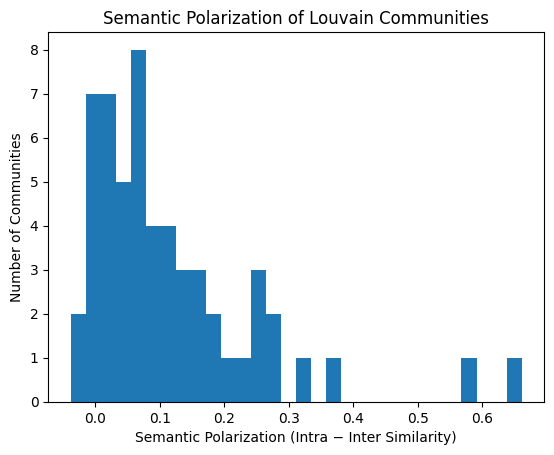

In [ ]:
import matplotlib.pyplot as plt

plt.hist(pol_df["polarization"], bins=30)
plt.xlabel("Semantic Polarization (Intra − Inter Similarity)")
plt.ylabel("Number of Communities")
plt.title("Semantic Polarization of Louvain Communities")
plt.show()


<Axes: xlabel='size', ylabel='polarization'>

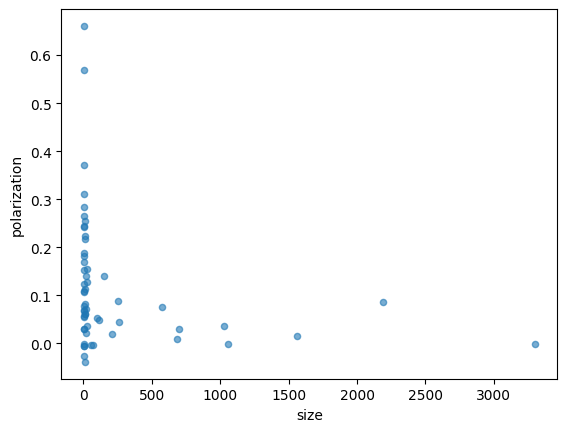

In [ ]:
# community size v.s. polarisation
pol_df.plot.scatter(
    x="size",
    y="polarization",
    alpha=0.6
)


## Bertopic

In [ ]:
df_node.head()

,node,text,node_emb
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0..."
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0..."
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049..."
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05..."
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0..."


In [ ]:
embs = np.stack(df_node['node_emb'].values)

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.5 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

stop_words = list(CountVectorizer(stop_words="english").get_stop_words())
stop_words.extend([
    'unknown', 'title', 'untitled', 'just', 'post', 'check',
    'new', 'items', 'shared', 'link', 'fwd', 'tramite', 'amp',
    'zero', 'anche', 'nuovo', 'italiano'
])
vectorizer_model = CountVectorizer(
    stop_words=stop_words,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2)
)


cluster_model = KMeans(n_clusters=20)
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    hdbscan_model=cluster_model,
    language="english",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(
    emb_df["text"].tolist(),
    embs
)


2026-01-06 15:21:04,303 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-06 15:21:15,266 - BERTopic - Dimensionality - Completed ✓
2026-01-06 15:21:15,268 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-06 15:21:15,347 - BERTopic - Cluster - Completed ✓
2026-01-06 15:21:15,356 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-06 15:21:44,878 - BERTopic - Representation - Completed ✓


In [ ]:
emb_df["topic_id"] = topics
emb_df.head()

,node,text,node_emb,community,idx,topic_id
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0...",59,0,11
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0...",5,1,14
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049...",2,2,1
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05...",3,3,4
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0...",53,4,2


In [ ]:
emb_df["topic_id"].value_counts()

,count
topic_id,
0,1251
1,1105
2,935
3,893
4,790
5,770
6,741
7,736
8,688


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,1251,0_eur_1695_1495_1295,"[eur, 1695, 1495, 1295, 1895, 1195, 895, 995, ...",[Built to Spill Get an 80’s Makeover - Drake “...
1,1,1105,1_wines_vineyard_chardonnay_kona,"[wines, vineyard, chardonnay, kona, cabernet, ...",[From solemn to silly in six seconds. Born to ...
2,2,935,2_aapl_goog_msft_antivirus,"[aapl, goog, msft, antivirus, aapl goog, silve...",[Facebook Is Now The Best Tech Company To Work...
3,3,893,3_voss_twitter app_app review_review video,"[voss, twitter app, app review, review video, ...",[Facebook Wins Facebook.Me Domain: New Product...
4,4,790,4_great price_air jordan_sale best_buy cheap,"[great price, air jordan, sale best, buy cheap...",[Zombie Spaceship Wasteland: A Book by Patton ...
5,5,770,5_influential people_2010s influential_searchi...,"[influential people, 2010s influential, search...",[Taking the Mystery Out of Scaling a Company -...
6,6,741,6_drs_celebrity gossip_gossip celebrity_lastest,"[drs, celebrity gossip, gossip celebrity, last...",[DR's Love Update education department : Diale...
7,7,736,7_message world_div_internet free_office 2010,"[message world, div, internet free, office 201...",[Radyo Ex suna: Bir çeşit ruh hali diyerek Sys...
8,8,688,8_ipa_4g_android 22_android tablet,"[ipa, 4g, android 22, android tablet, htc desi...",[Infineon Said to Seek 1.5 Billion Euros for I...
9,9,638,9_lightbox_creative commons_photo best_best vi...,"[lightbox, creative commons, photo best, best ...","[Fwd: Fwd: There are -3 types of being ready, ..."


In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.save("/content/drive/MyDrive/UU/MSD/topic_model", serialization="pickle")

2026-01-06 15:27:21,968 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
emb_df.to_pickle('/content/drive/MyDrive/UU/MSD/df_node_results.pkl')

In [ ]:
loaded_model = BERTopic.load("/content/drive/MyDrive/UU/MSD/topic_model")

In [ ]:
len(df_node)

12670

## Topic network

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

# --- 步骤 A: 准备数据 (在函数外计算，保证绘图时可用) ---

# 1. 获取每个话题的用户数 (用于归一化和节点大小)
topic_sizes = emb_df['topic_id'].value_counts().to_dict()

# 2. 建立 用户 -> 话题 的映射
node_to_topic = dict(zip(emb_df['node'], emb_df['topic_id']))

# --- 步骤 B: 构建网络的函数 ---
def get_topic_network(G_user, node_map, sizes):
    # 初始化一个新的无向图
    G_topic = nx.Graph()

    # 遍历用户网络中的每一条边
    # u, v 是用户节点, data 包含权重
    for u, v, data in G_user.edges(data=True):

        # 确保两个用户都在我们的映射表中 (有些用户可能被清洗掉了)
        if u in node_map and v in node_map:
            t_u = node_map[u] # 用户 u 的话题
            t_v = node_map[v] # 用户 v 的话题

            # 只有当属于不同话题时才连线 (如果需要包含话题内部互动，去掉这个if)
            if t_u != t_v:
                # 获取原始权重，如果没有默认为 1
                w = data.get('weight', 1)

                # 累加原始互动次数
                if G_topic.has_edge(t_u, t_v):
                    G_topic[t_u][t_v]['raw_interaction'] += w
                else:
                    G_topic.add_edge(t_u, t_v, raw_interaction=w)

    # 计算归一化权重
    # 公式：权重 = 总互动次数 / (话题A人数 * 话题B人数)
    for u, v, data in G_topic.edges(data=True):
        raw = data['raw_interaction']
        size_u = sizes[u]
        size_v = sizes[v]

        # 归一化处理
        norm_weight = raw / (size_u * size_v)
        G_topic[u][v]['weight'] = norm_weight

    return G_topic

# --- 步骤 C: 生成网络 ---
topic_net = get_topic_network(G_gc, node_to_topic, topic_sizes)

print(f"话题网络构建完成：包含 {topic_net.number_of_nodes()} 个节点, {topic_net.number_of_edges()} 条边")

话题网络构建完成：包含 20 个节点, 190 条边


In [ ]:
import networkx as nx

# 1. 加权度 (Weighted Degree) - "社交之王"
# 代表：该话题与其他话题互动的总强度（归一化后）。
# 谁最高：说明这个话题的用户最喜欢“跨圈”交流。
degree_dict = dict(topic_net.degree(weight='weight'))
sorted_degree = sorted(degree_dict.items(), key=lambda item: item[1], reverse=True)

# 2. 中介中心度 (Betweenness Centrality) - "桥梁"
# 代表：该话题是否处于最短路径上。
# 谁最高：说明它是连接不同圈子（比如连接“科技”和“娱乐”）的关键枢纽。
# 注意：这里我们只看拓扑结构，不加权重，因为networkx的权重默认为距离
betweenness_dict = nx.betweenness_centrality(topic_net)
sorted_betweenness = sorted(betweenness_dict.items(), key=lambda item: item[1], reverse=True)

# --- 打印分析报告 ---
print("=== 🌟 加权度最高 (最活跃的跨界话题) ===")
for node, score in sorted_degree[:5]:
    print(f"Topic {node} ({domain_names[domain_map[node]]}): Score {score:.5f}")

print("\n=== 🌉 中介中心度最高 (连接不同圈子的桥梁) ===")
for node, score in sorted_betweenness[:5]:
    print(f"Topic {node} ({domain_names[domain_map[node]]}): Score {score:.5f}")

print("\n=== 🏝️ 加权度最低 (最封闭的垂直圈子) ===")
for node, score in sorted_degree[-5:]:
    print(f"Topic {node} ({domain_names[domain_map[node]]}): Score {score:.5f}")

=== 🌟 加权度最高 (最活跃的跨界话题) ===
Topic 1 (Lifestyle): Score 0.10801
Topic 11 (Politics): Score 0.06610
Topic 17 (Politics): Score 0.06271
Topic 10 (Tech): Score 0.06255
Topic 14 (Lifestyle): Score 0.06212

=== 🌉 中介中心度最高 (连接不同圈子的桥梁) ===
Topic 11 (Politics): Score 0.00000
Topic 9 (General): Score 0.00000
Topic 3 (Tech): Score 0.00000
Topic 1 (Lifestyle): Score 0.00000
Topic 10 (Tech): Score 0.00000

=== 🏝️ 加权度最低 (最封闭的垂直圈子) ===
Topic 7 (General): Score 0.01976
Topic 3 (Tech): Score 0.01793
Topic 19 (Entertainment): Score 0.01751
Topic 15 (Tech): Score 0.01585
Topic 16 (Business): Score 0.00377


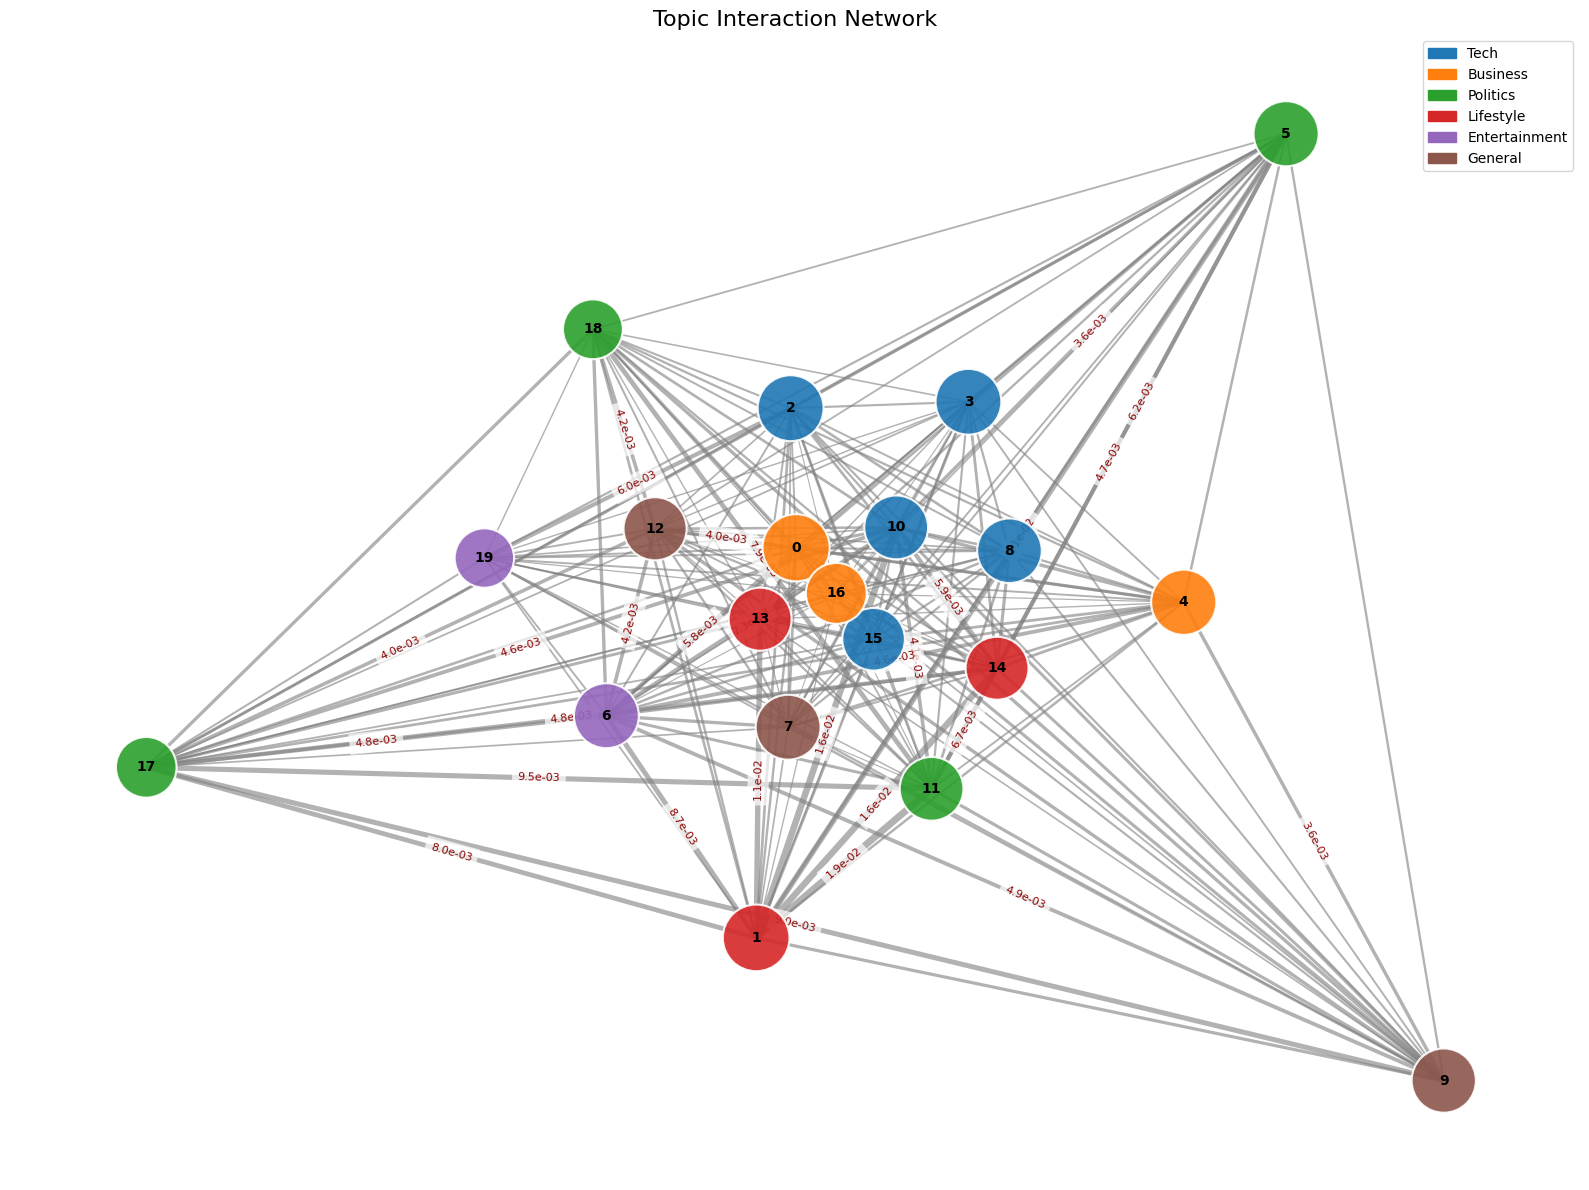

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
import numpy as np

# ===========================
# 1. 数据准备 (同上，不再赘述，假设 topic_net 已生成)
# ===========================
# 如果前面没定义 domain_map，这里补充一下
if 'domain_map' not in locals():
    domain_map = {
        2: 1, 3: 1, 8: 1, 10: 1, 15: 1, # Tech
        0: 2, 4: 2, 16: 2, # Business
        5: 3, 11: 3, 17: 3, 18: 3, # Politics
        1: 4, 13: 4, 14: 4, # Lifestyle
        6: 5, 19: 5, # Entertainment
        7: 6, 9: 6, 12: 6 # General
    }

# ===========================
# 2. 视觉参数计算
# ===========================

# --- A. 布局算法优化 (关键) ---
# 使用 Kamada-Kawai 算法，它比 spring 更擅长展示社群结构，不会让节点围成圈
pos = nx.kamada_kawai_layout(topic_net)
# 或者如果还想用 spring，必须调小 k 值：
# pos = nx.spring_layout(topic_net, k=0.3, iterations=100, seed=42)

# --- B. 线宽的非线性映射 (关键) ---
# 获取所有权重
weights = np.array([d['weight'] for u, v, d in topic_net.edges(data=True)])

# 归一化权重到 0~1 之间
w_min = weights.min()
w_max = weights.max()
# 避免除以零
if w_max - w_min == 0:
    norm_weights = weights
else:
    norm_weights = (weights - w_min) / (w_max - w_min)

# 映射线宽：最细 0.5，最粗 5.0
# 使用 power=0.5 (开方) 让细线稍微变粗一点，更容易被看见
edge_widths = [0.5 + 4.5 * (w ** 0.5) for w in norm_weights]

# --- C. 边标签筛选 ---
edge_labels = {}
# 只显示最强的 15% 的边的数值，避免杂乱
threshold_val = np.percentile(weights, 85)
for u, v, d in topic_net.edges(data=True):
    if d['weight'] >= threshold_val:
        edge_labels[(u, v)] = "{:.1e}".format(d['weight'])

# --- D. 节点颜色和大小 ---
cmap = plt.get_cmap('tab10')
node_colors = [cmap(domain_map.get(n, 0) - 1) for n in topic_net.nodes()]
# 节点大小：基础大小 200 + 根据人数对数缩放
node_sizes = [200 + np.log(topic_sizes[n] + 1) * 300 for n in topic_net.nodes()]

# ===========================
# 3. 绘图执行
# ===========================
plt.figure(figsize=(16, 12)) # 画布大一点

# 先画边 (Edge)
nx.draw_networkx_edges(topic_net, pos,
                       width=edge_widths,
                       edge_color='gray',
                       alpha=0.6) # 稍微透明，更有层次感

# 再画节点 (Node)
nx.draw_networkx_nodes(topic_net, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       alpha=0.9,
                       edgecolors='white',
                       linewidths=1.5)

# 画节点标签 (Topic ID)
nx.draw_networkx_labels(topic_net, pos, font_size=10, font_weight='bold', font_color='black')

# 画边权重标签 (Edge Label) - 带白色背景框，防止看不清
nx.draw_networkx_edge_labels(topic_net, pos,
                             edge_labels=edge_labels,
                             font_size=8,
                             font_color='darkred',
                             bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# 添加简单的图例
domain_names = {
    1: "Tech", 2: "Business", 3: "Politics",
    4: "Lifestyle", 5: "Entertainment", 6: "General"
}
patches = [mpatches.Patch(color=cmap(i-1), label=label) for i, label in domain_names.items()]
plt.legend(handles=patches, loc='best')

plt.title("Topic Interaction Network", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

## Community v.s. Topic

In [ ]:
import joblib
emb_df = joblib.load('/content/drive/MyDrive/UU/MSD/df_node_results.pkl')

emb_df.head()

,node,text,node_emb,community,idx,topic_id
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0...",59,0,11
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0...",5,1,14
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049...",2,2,1
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05...",3,3,4
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0...",53,4,2


In [ ]:
import pandas as pd

ct = pd.crosstab(
    emb_df["community"],
    emb_df["topic_id"]
)


In [ ]:
# normalisation
ct_norm = ct.div(ct.sum(axis=1), axis=0)


### Top-N 社区 × Top-M Topics 热力图

In [ ]:
top_communities = (
    emb_df["community"]
    .value_counts()
    .head(20)
    .index
)

top_topics = (
    emb_df["topic_id"]
    .value_counts()
    .drop(-1, errors="ignore")
    .head(10)
    .index
)


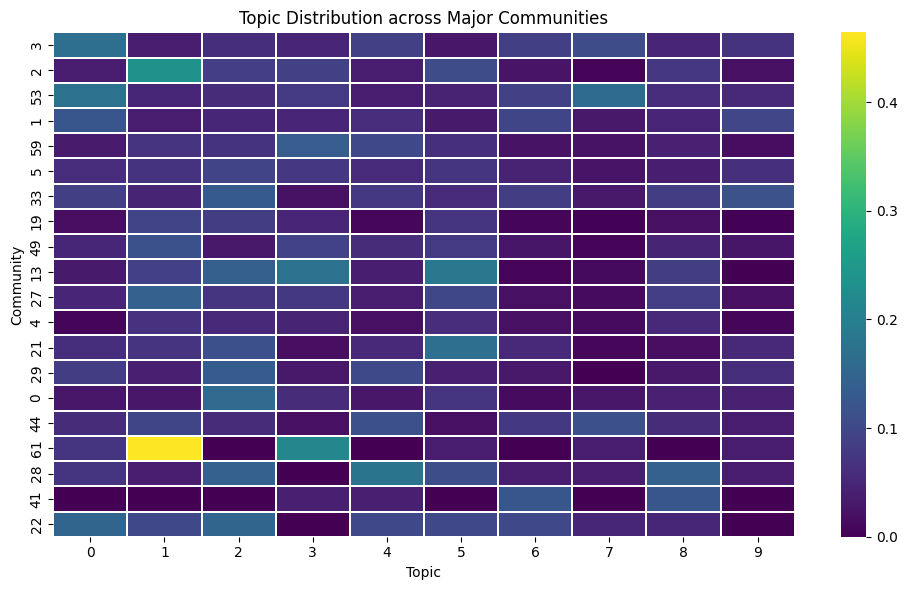

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(
    ct_norm.loc[top_communities, top_topics],
    cmap="viridis",
    linewidths=0.3
)
plt.xlabel("Topic")
plt.ylabel("Community")
plt.title("Topic Distribution across Major Communities")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

emb_df['node_emb'] = emb_df['node_emb'].apply(np.array)


In [ ]:
emb_df.head()

,node,text,node_emb,community,idx,topic_id
0,02myfrifeed01,Japan: Boat racing on Edogawa river - Taiwan: ...,"[-0.024345804, 0.044006918, -0.0043728794, 0.0...",59,0,11
1,0boy,Create an Epic Battle Field in Photoshop | Gra...,"[-0.066298805, -0.021350043, 0.036989458, -0.0...",5,1,14
2,0bpm,JoeJoCollage-27x36 - What's better than gettin...,"[0.015317391, 0.014721517, 0.046485335, 0.0049...",2,2,1
3,0kqokce,Range Rover 2008 Supercharged // Off Road Time...,"[-0.030357828, 0.005804373, 0.031557634, -0.05...",3,3,4
4,0m4r,Berlin Polar Bear Alone at Home: Knut Relieved...,"[-0.060475595, -0.025443017, 0.027896618, -0.0...",53,4,2


### Echo chamber

In [ ]:
import pandas as pd

topic_comm_dist = (
    emb_df
    .groupby(['topic_id', 'community'])
    .size()
    .reset_index(name='count')
)

# 每个 topic 的总节点数
topic_total = topic_comm_dist.groupby('topic_id')['count'].sum()

topic_comm_dist['p'] = topic_comm_dist.apply(
    lambda r: r['count'] / topic_total.loc[r['topic_id']],
    axis=1
)


In [ ]:
from scipy.stats import entropy

topic_entropy = (
    topic_comm_dist
    .groupby('topic_id')['p']
    .apply(lambda x: entropy(x))
    .reset_index(name='entropy')
)

topic_entropy.head()


,topic_id,entropy
0,0,1.819935
1,1,2.087334
2,2,2.447755
3,3,2.339879
4,4,2.200940


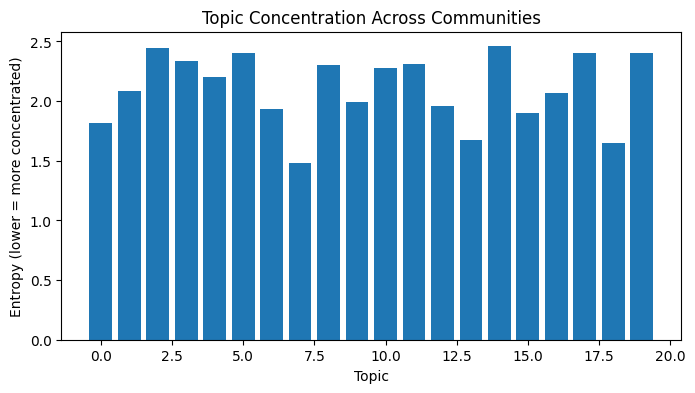

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(topic_entropy['topic_id'], topic_entropy['entropy'])
plt.xlabel("Topic")
plt.ylabel("Entropy (lower = more concentrated)")
plt.title("Topic Concentration Across Communities")
plt.show()


- 低 entropy → topic 主要集中在少数社区

- 高 entropy → topic 广泛分布

#### Embed_based distance

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def avg_cosine_similarity(embs):
    if len(embs) < 2:
        return np.nan
    sim = cosine_similarity(embs)
    upper = sim[np.triu_indices_from(sim, k=1)]
    return upper.mean()


In [ ]:
topic_intra = []

for topic, df_t in emb_df.groupby('topic_id'):
    for comm, df_c in df_t.groupby('community'):
        sim = avg_cosine_similarity(np.stack(df_c['node_emb']))
        topic_intra.append({
            'topic_id': topic,
            'community': comm,
            'intra_sim': sim,
            'n': len(df_c)
        })

topic_intra_df = pd.DataFrame(topic_intra)


In [ ]:
topic_intra_summary = (
    topic_intra_df
    .dropna()
    .groupby('topic_id')
    .apply(lambda x: np.average(x['intra_sim'], weights=x['n']))
    .reset_index(name='intra_sim')
)


/tmp/ipython-input-1122094319.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x['intra_sim'], weights=x['n']))


In [ ]:
topic_inter = []

for topic, df_t in emb_df.groupby('topic_id'):
    embs = np.stack(df_t['node_emb'])
    comms = df_t['community'].values

    sims = cosine_similarity(embs)

    mask = comms[:, None] != comms[None, :]
    topic_inter.append({
        'topic_id': topic,
        'inter_sim': sims[mask].mean()
    })

topic_inter_df = pd.DataFrame(topic_inter)


In [ ]:
topic_metrics = (
    topic_entropy
    .merge(topic_intra_summary, on='topic_id')
    .merge(topic_inter_df, on='topic_id')
)

topic_metrics['echo_index'] = (
    topic_metrics['intra_sim'] - topic_metrics['inter_sim']
)


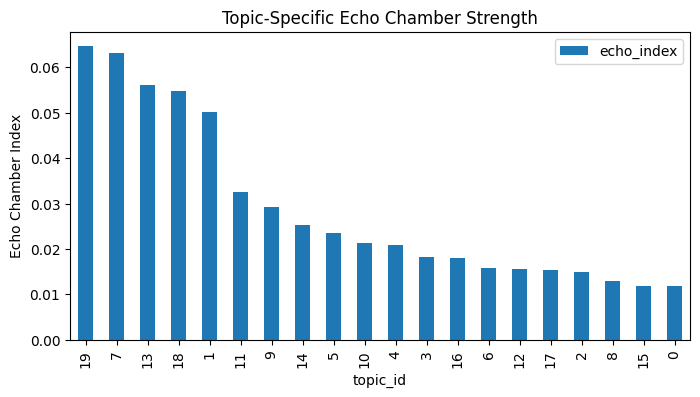

In [ ]:
topic_metrics.sort_values('echo_index', ascending=False).plot(
    x='topic_id', y='echo_index', kind='bar', figsize=(8,4)
)
plt.ylabel("Echo Chamber Index")
plt.title("Topic-Specific Echo Chamber Strength")
plt.show()


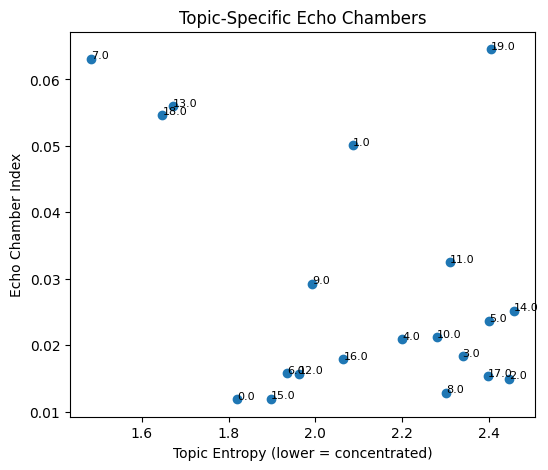

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    topic_metrics['entropy'],
    topic_metrics['echo_index']
)

for _, r in topic_metrics.iterrows():
    plt.text(r['entropy'], r['echo_index'], str(r['topic_id']), fontsize=8)

plt.xlabel("Topic Entropy (lower = concentrated)")
plt.ylabel("Echo Chamber Index")
plt.title("Topic-Specific Echo Chambers")
plt.show()


Figure above shows the relationship between topic concentration across communities (entropy) and topic-specific echo chamber strength.

While most topics cluster in the region of moderate entropy and low echo chamber index, a small subset of topics exhibits both low entropy and high echo chamber indices. These topics correspond primarily to political conflict and culture war–related discussions, suggesting the presence of topic-specific echo chambers.

In contrast, technology, entertainment, and consumer-oriented topics are widely distributed across communities and show limited evidence of echo-chamber behavior.

In [ ]:
topic_metrics['category'] = topic_metrics['topic_id'].map({
    18: 'political',
    17: 'political',
    7: 'political',
    2: 'tech',
    8: 'tech',
    6: 'entertainment',
    # 其余 'other'
}).fillna('other')
s

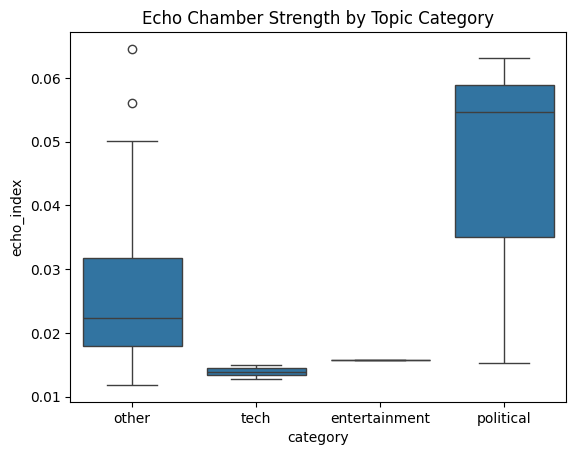

In [ ]:
import seaborn as sns

sns.boxplot(
    data=topic_metrics,
    x='category',
    y='echo_index'
)
plt.title("Echo Chamber Strength by Topic Category")
plt.show()


### 每个社区的「Topic 集中度」

In [ ]:
import numpy as np

def entropy(p):
    p = p[p > 0]
    return -np.sum(p * np.log(p))

community_entropy = ct_norm.apply(entropy, axis=1)


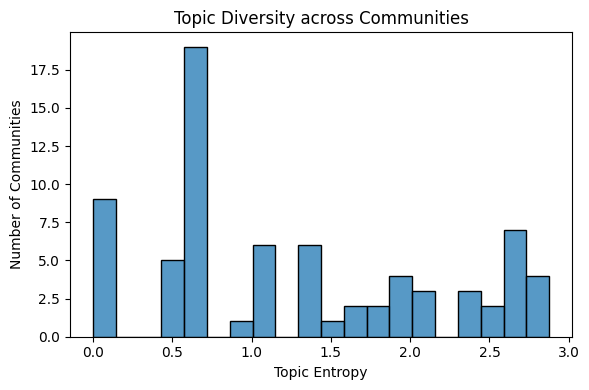

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(community_entropy, bins=20)
plt.xlabel("Topic Entropy")
plt.ylabel("Number of Communities")
plt.title("Topic Diversity across Communities")
plt.tight_layout()
plt.show()


### UMAP + 社区 / Topic（抽样）

In [ ]:
sample_df = (
    emb_df
    .groupby("community", group_keys=False)
    .apply(lambda x: x.sample(min(50, len(x)), random_state=42))
)


/tmp/ipython-input-4177811749.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(50, len(x)), random_state=42))


In [ ]:
import umap

X_sample = np.vstack(sample_df["node_emb"])
X_2d = umap.UMAP(
    n_components=2,
    metric="cosine",
    random_state=42
).fit_transform(X_sample)

sample_df["x"] = X_2d[:,0]
sample_df["y"] = X_2d[:,1]


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


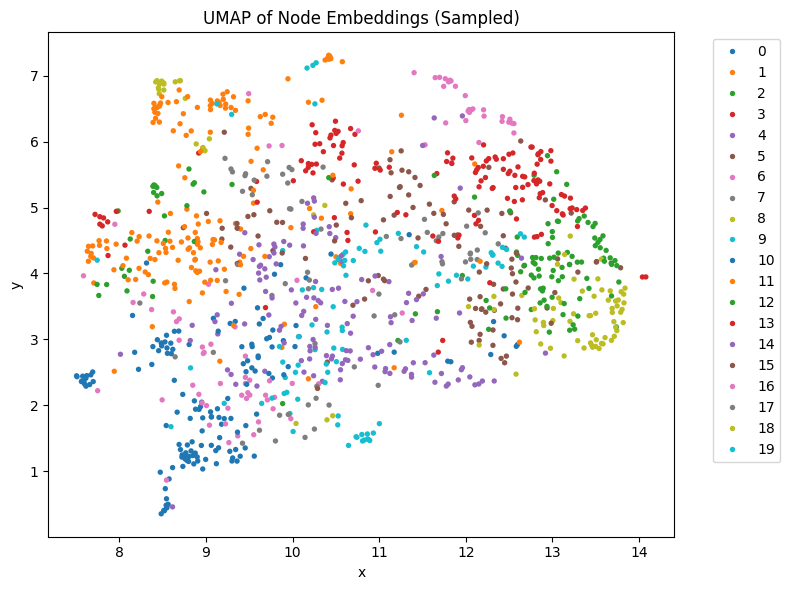

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=sample_df,
    x="x",
    y="y",
    hue="topic_id",
    palette="tab10",
    s=15,
    linewidth=0
)
plt.title("UMAP of Node Embeddings (Sampled)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import normalized_mutual_info_score

nmi = normalized_mutual_info_score(
    emb_df["community"],
    emb_df["topic_id"]
)
print("NMI (community vs topic):", nmi)


NMI (community vs topic): 0.1113630674429794


In [ ]:
top_comms = (
    emb_df["community"]
    .value_counts()
    .head(12)      # 建议 6–12
    .index
)

plot_df = sample_df[sample_df["community"].isin(top_comms)]


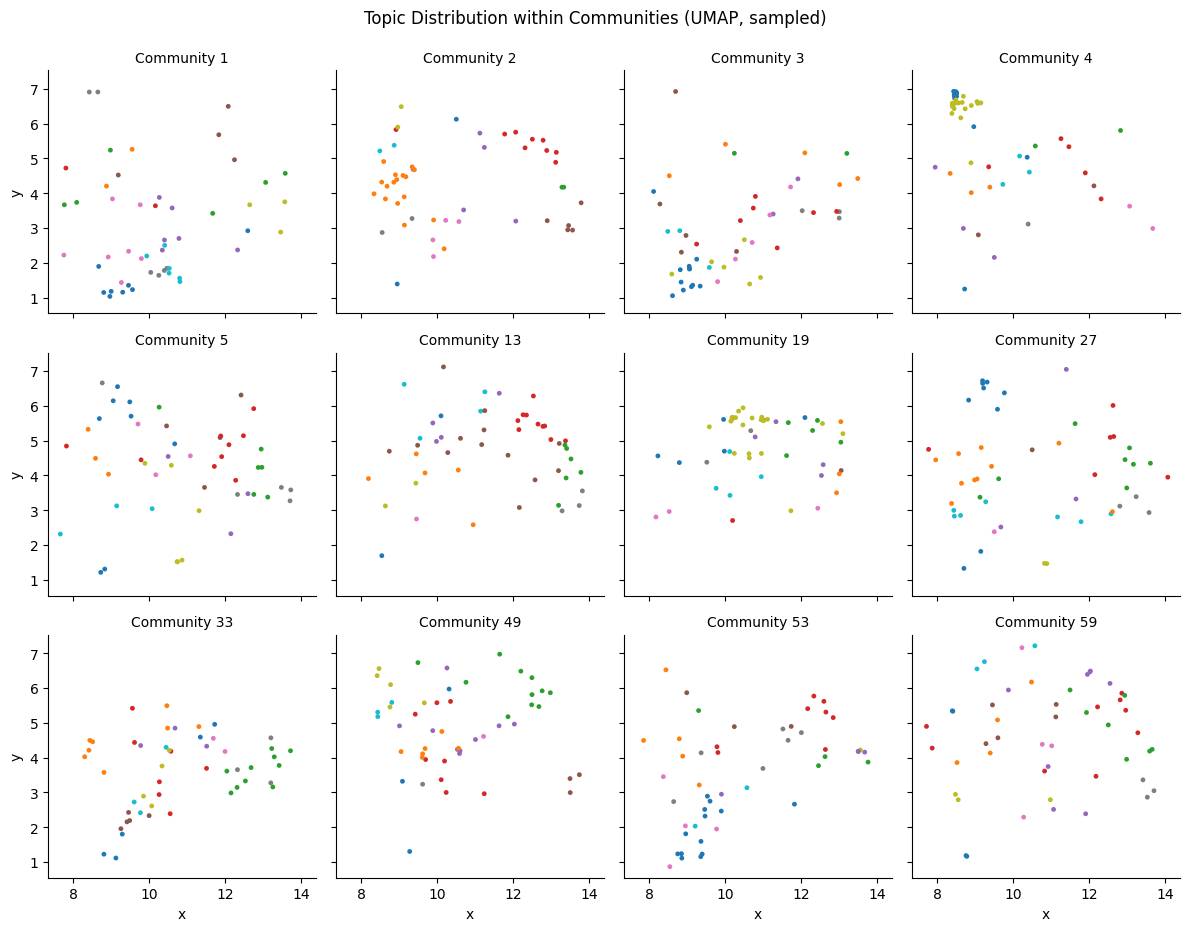

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    plot_df,
    col="community",
    col_wrap=4,
    height=3,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="x",
    y="y",
    hue="topic_id",
    palette="tab10",
    s=12,
    linewidth=0,
    legend=False
)

g.set_titles("Community {col_name}")
g.fig.suptitle("Topic Distribution within Communities (UMAP, sampled)", y=1.03)
plt.show()


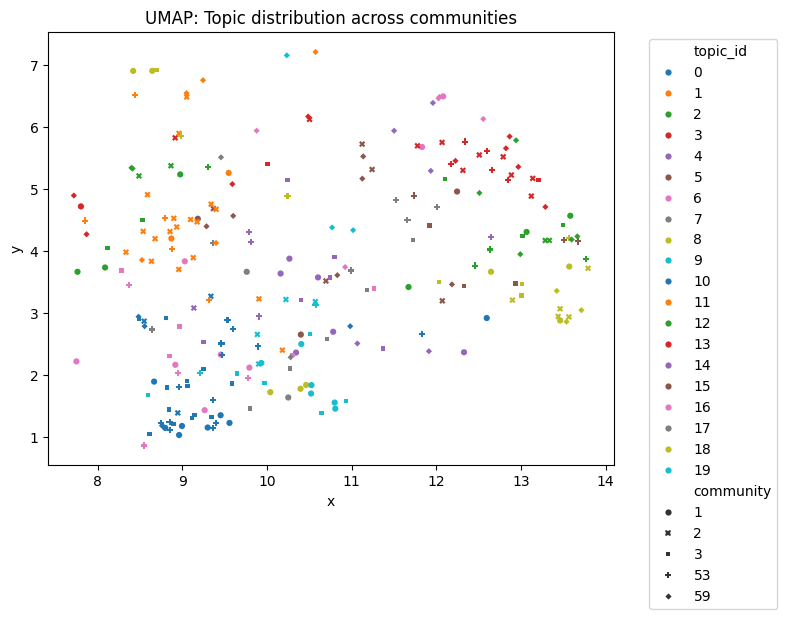

In [ ]:
small_df = sample_df[sample_df["community"].isin(top_comms[:5])]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=small_df,
    x="x",
    y="y",
    hue="topic_id",
    style="community",
    palette="tab10",
    s=20,
    linewidth=0
)

plt.title("UMAP: Topic distribution across communities")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
emb_df.columns

Index(['node', 'text', 'node_emb', 'community', 'idx', 'topic_id'], dtype='object')

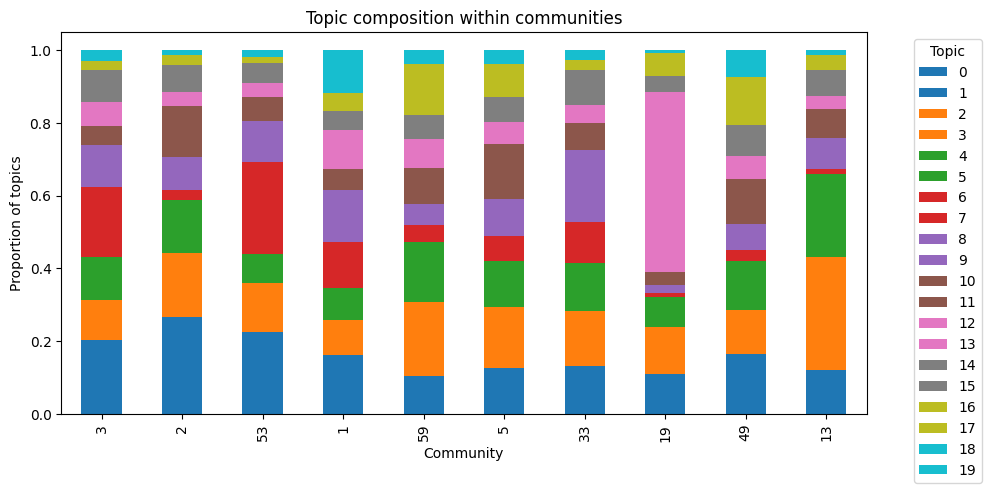

In [ ]:
top_comms = emb_df["community"].value_counts().head(10).index
plot_mat = ct_norm.loc[top_comms].drop(-1, axis=1, errors="ignore")

plot_mat.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    colormap="tab10"
)

plt.ylabel("Proportion of topics")
plt.xlabel("Community")
plt.title("Topic composition within communities")
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
